# Model Evaluation

Evaluate `best_model_mobilenet.pth` on the held-out test split.

Goals:
- Confusion matrix
- Per-class accuracy
- Overall accuracy vs 90% target

In [ ]:
# ── Cell 2 — Imports & Config ─────────────────────────────────────────
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import json , sys, os
from pathlib import Path
import config

# ── paths ────────────────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath(".."))
BASE_DIR    = Path(config.BASE_DIR)
MODEL_PATH  = BASE_DIR / "models/saved/best_model_mobilenet.pth"
DATA_DIR    = Path(config.KAGGLE_ASL_PATH)
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# ── constants ────────────────────────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 64
NUM_CLASSES = 29
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {DEVICE}")
print(f"Model path  : {MODEL_PATH}")
print(f"Data dir    : {DATA_DIR}")
print(f"Results dir : {RESULTS_DIR}")

Device      : cuda
Model path  : C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\models\saved\best_model_mobilenet.pth
Data dir    : C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\data\raw\kaggle_asl\ASL_Alphabet_Dataset\asl_alphabet_train
Results dir : C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\results


In [13]:
# ── Cell 3 — Test DataLoader (20% stratified split) ───────────────────
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

# load full dataset with test transforms (no augmentation)
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=test_transform)
CLASS_NAMES  = full_dataset.classes
all_targets  = full_dataset.targets  # class index per sample

# stratified 80/20 split — same seed as training to avoid data leakage
train_idx, test_idx = train_test_split(
    range(len(full_dataset)),
    test_size=0.20,
    stratify=all_targets,
    random_state=42,
)

test_dataset = Subset(full_dataset, test_idx)
test_loader  = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print(f"Full dataset   : {len(full_dataset):,} images")
print(f"Test split 20% : {len(test_dataset):,} images")
print(f"Classes ({len(CLASS_NAMES)})  : {CLASS_NAMES}")

Full dataset   : 223,074 images
Test split 20% : 44,615 images
Classes (29)  : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [18]:
# ── Cell 4 — Rebuild & Load Model ────────────────────────────────────
def build_model(num_classes: int) -> nn.Module:
    model = models.mobilenet_v2(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),              # 0 — matches default structure
        nn.Linear(1280, 512),         # 1 — classifier.1.weight [512, 1280]
        nn.ReLU(),                    # 2
        nn.Dropout(0.2),              # 3
        nn.Linear(512, num_classes),  # 4 — classifier.4.weight [29, 512]
    )
    return model

model      = build_model(NUM_CLASSES)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint.get("model_state_dict", checkpoint)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

print(f"Loaded   : {MODEL_PATH.name}")
print(f"Size     : {MODEL_PATH.stat().st_size / 1e6:.2f} MB")
if "epoch" in checkpoint:
    print(f"Saved at epoch {checkpoint['epoch']}  |  val_acc {checkpoint.get('val_acc', 'N/A')}")

Loaded   : best_model_mobilenet.pth
Size     : 11.83 MB


In [19]:
# ── Cell 5 — Inference Loop ───────────────────────────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(test_loader)} processed...")

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

overall_acc = (all_preds == all_labels).mean() * 100
print(f"\nOverall test accuracy : {overall_acc:.2f}%")
print(f"Target (90%)          : {'✓ PASSED' if overall_acc >= 90 else '⚠ FAILED'}")

  Batch 10/698 processed...
  Batch 20/698 processed...
  Batch 30/698 processed...
  Batch 40/698 processed...
  Batch 50/698 processed...
  Batch 60/698 processed...
  Batch 70/698 processed...
  Batch 80/698 processed...
  Batch 90/698 processed...
  Batch 100/698 processed...
  Batch 110/698 processed...
  Batch 120/698 processed...
  Batch 130/698 processed...
  Batch 140/698 processed...
  Batch 150/698 processed...
  Batch 160/698 processed...
  Batch 170/698 processed...
  Batch 180/698 processed...
  Batch 190/698 processed...
  Batch 200/698 processed...
  Batch 210/698 processed...
  Batch 220/698 processed...
  Batch 230/698 processed...
  Batch 240/698 processed...
  Batch 250/698 processed...
  Batch 260/698 processed...
  Batch 270/698 processed...
  Batch 280/698 processed...
  Batch 290/698 processed...
  Batch 300/698 processed...
  Batch 310/698 processed...
  Batch 320/698 processed...
  Batch 330/698 processed...
  Batch 340/698 processed...
  Batch 350/698 process

In [20]:
# ── Cell 6 — Per-Class Accuracy Table ────────────────────────────────
report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

print(f"{'Class':<10} {'Precision':>10} {'Recall':>8} {'F1':>6} {'Support':>9}")
print("-" * 50)
for cls in CLASS_NAMES:
    r = report[cls]
    print(f"{cls:<10} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1-score']:>6.4f} {int(r['support']):>9}")

print(f"\n{'Macro avg':<10} {report['macro avg']['precision']:>10.4f} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>6.4f}")
print(f"{'Weighted':<10} {report['weighted avg']['precision']:>10.4f} {report['weighted avg']['recall']:>8.4f} {report['weighted avg']['f1-score']:>6.4f}")

# save JSON for later steps
with open(RESULTS_DIR / "classification_report.json", "w") as f:
    json.dump(report, f, indent=2)
print("\nSaved → results/classification_report.json")

Class       Precision   Recall     F1   Support
--------------------------------------------------
A              0.9926   0.9468 0.9691      1692
B              0.9878   0.9741 0.9809      1662
C              0.9839   0.9779 0.9809      1629
D              0.9342   0.9299 0.9320      1526
E              0.9608   0.9658 0.9633      1549
F              0.8781   0.9732 0.9232      1606
G              0.8942   0.9477 0.9202      1569
H              0.8678   0.9880 0.9240      1581
I              0.9521   0.9497 0.9509      1591
J              0.9722   0.9320 0.9517      1500
K              0.9808   0.9721 0.9764      1575
L              0.9981   0.9673 0.9824      1588
M              0.9944   0.9019 0.9459      1580
N              0.9518   0.9344 0.9430      1586
O              0.9231   0.9883 0.9546      1628
P              0.9712   0.9533 0.9622      1520
Q              0.9054   0.9629 0.9333      1591
R              0.9215   0.9589 0.9398      1604
S              0.9598   0.9273 0.9432

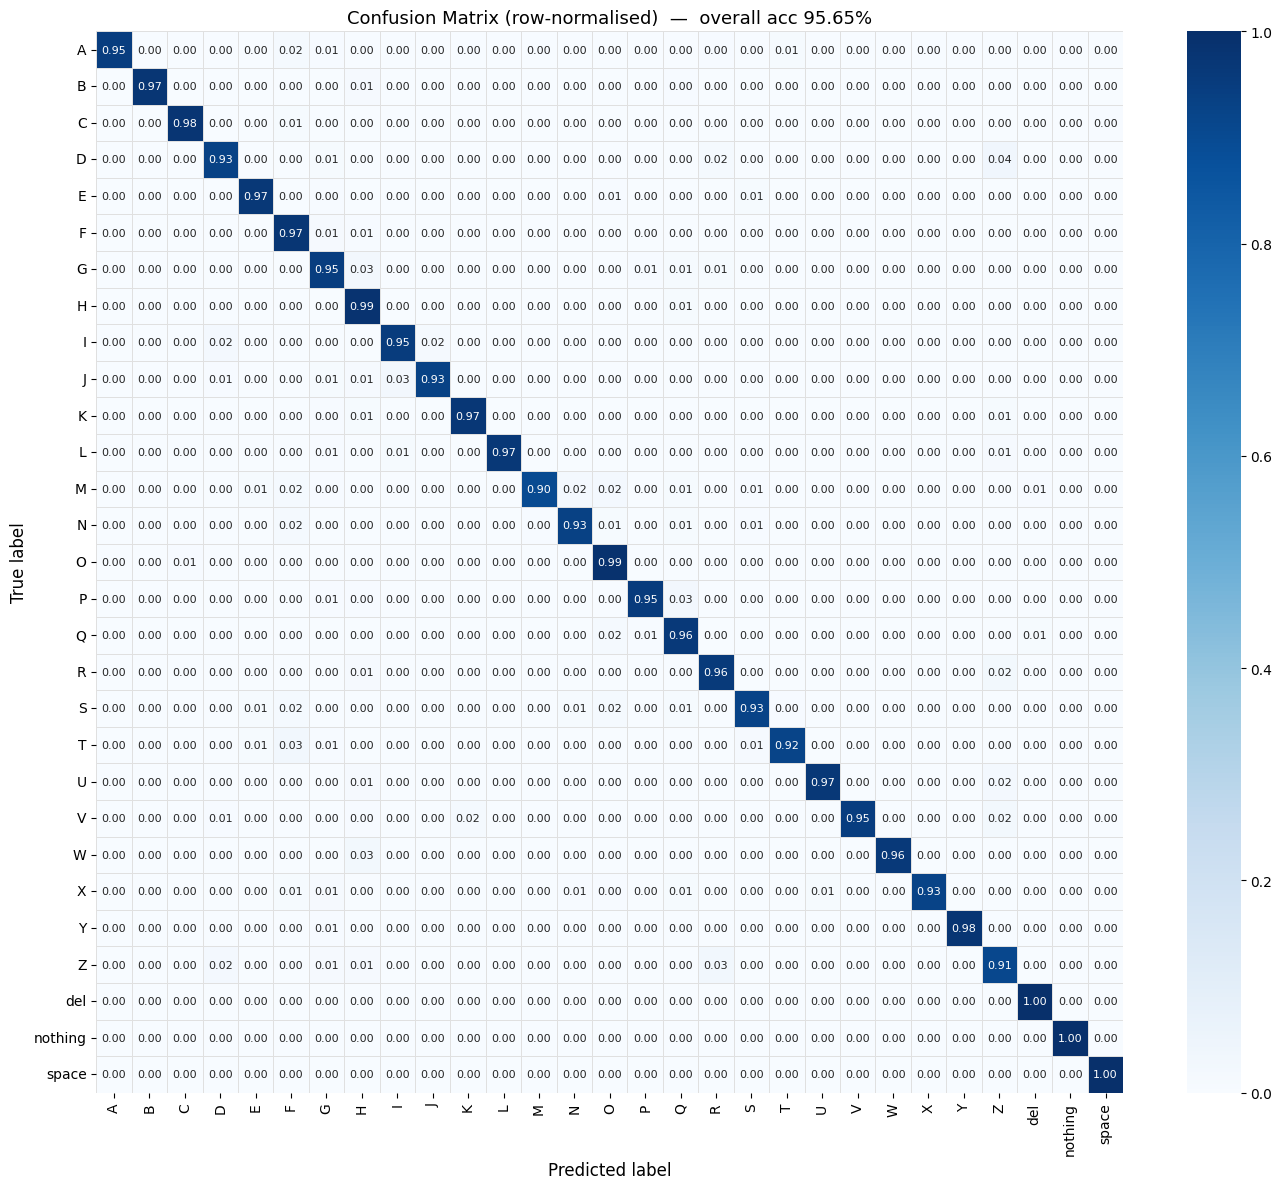

Saved → results/confusion_matrix.png


In [21]:
# ── Cell 7 — Confusion Matrix ─────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues",
    linewidths=0.4,
    linecolor="#e0e0e0",
    ax=ax,
    vmin=0, vmax=1,
    annot_kws={"size": 8},
)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)
ax.set_title(
    f"Confusion Matrix (row-normalised)  —  overall acc {overall_acc:.2f}%",
    fontsize=13
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()
print("Saved → results/confusion_matrix.png")

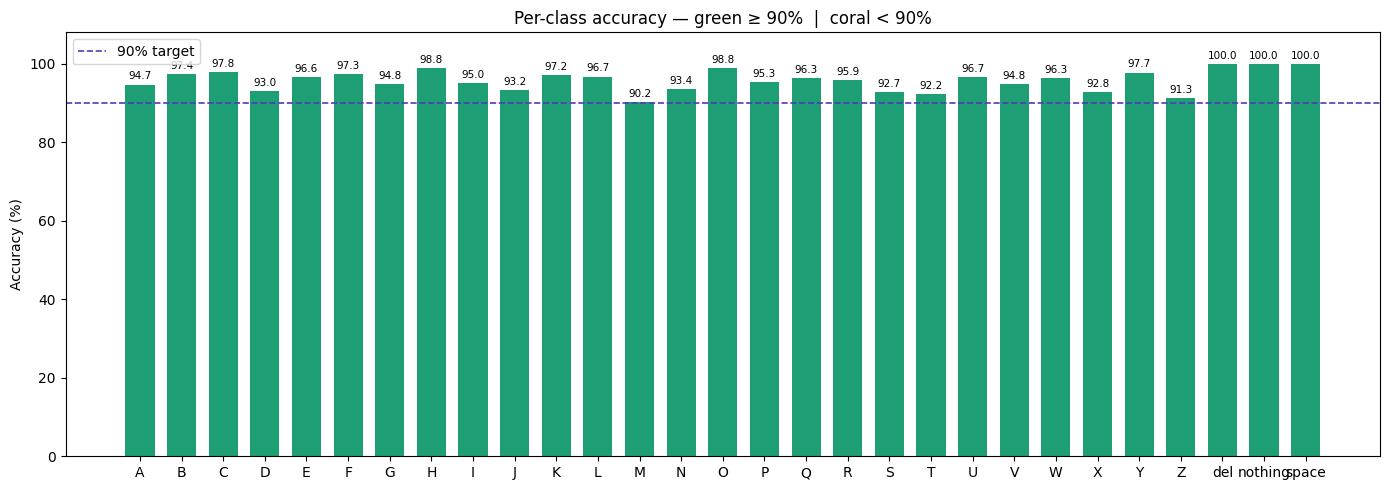

Saved → results/per_class_accuracy.png


In [22]:
# ── Cell 8 — Per-Class Accuracy Bar Chart ────────────────────────────
per_class_acc = cm_norm.diagonal() * 100   # recall == per-class accuracy

colors = ["#1D9E75" if a >= 90 else "#D85A30" for a in per_class_acc]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors, edgecolor="none", width=0.7)
ax.axhline(90, color="#533AB7", linewidth=1.2, linestyle="--", label="90% target")
ax.set_ylim(0, 108)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-class accuracy — green ≥ 90%  |  coral < 90%")
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{acc:.1f}",
        ha="center", va="bottom", fontsize=7.5
    )
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_accuracy.png", dpi=150)
plt.show()
print("Saved → results/per_class_accuracy.png")

In [23]:
# ── Cell 9 — Summary & Save Metrics JSON ─────────────────────────────
worst5 = sorted(zip(CLASS_NAMES, per_class_acc), key=lambda x: x[1])[:5]
best5  = sorted(zip(CLASS_NAMES, per_class_acc), key=lambda x: x[1], reverse=True)[:5]

print("── Evaluation Summary ──────────────────────────────────────")
print(f"  Overall accuracy  : {overall_acc:.2f}%")
print(f"  90% target        : {'✓ PASSED' if overall_acc >= 90 else '✗ FAILED'}")
print(f"  Classes >= 90%    : {sum(a >= 90 for a in per_class_acc)} / {NUM_CLASSES}")
print(f"  Classes < 90%     : {sum(a < 90 for a in per_class_acc)} / {NUM_CLASSES}")
print("\n  Top-5 classes:")
for cls, acc in best5:
    print(f"    {cls:<10} {acc:.2f}%")
print("\n  Bottom-5 classes:")
for cls, acc in worst5:
    print(f"    {cls:<10} {acc:.2f}%")

metrics = {
    "step"              : 10,
    "model"             : "MobileNetV2",
    "checkpoint"        : MODEL_PATH.name,
    "overall_accuracy"  : round(float(overall_acc), 4),
    "target_passed"     : bool(overall_acc >= 90),
    "num_classes"       : NUM_CLASSES,
    "per_class_accuracy": {
        cls: round(float(a), 4)
        for cls, a in zip(CLASS_NAMES, per_class_acc)
    },
}
with open(RESULTS_DIR / "eval_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nSaved → results/eval_metrics.json")
print("────────────────────────────────────────────────────────────")
print("Step 10 complete. Ready for Step 11.")

── Evaluation Summary ──────────────────────────────────────
  Overall accuracy  : 95.65%
  90% target        : ✓ PASSED
  Classes >= 90%    : 29 / 29
  Classes < 90%     : 0 / 29

  Top-5 classes:
    del        100.00%
    nothing    100.00%
    space      100.00%
    O          98.83%
    H          98.80%

  Bottom-5 classes:
    M          90.19%
    Z          91.30%
    T          92.24%
    S          92.73%
    X          92.84%

Saved → results/eval_metrics.json
────────────────────────────────────────────────────────────
Step 10 complete. Ready for Step 11.
